# 🧹 Module 07: Data Cleaning & Preprocessing
**Turning Raw, Messy Data into Analysis-Ready Data**

---

**Pre-requisite:** Module 06 (CRISP-DM Process)  
**Estimated time:** 4–5 hours  
**Session structure:** Why Clean → Types of Dirty Data → Hands-on Cleaning Techniques → Pipeline → Practice

---

## 📋 Table of Contents

| Part | Section | Topic |
|------|---------|-------|
| **Part 1: Why Clean?** | 1 | The Cost of Dirty Data |
| | 2 | The Garbage In, Garbage Out Principle |
| **Part 2: Types of Dirty Data** | 3 | The 5 Categories of Data Quality Issues |
| | 4 | Decision Framework — Which Fix to Apply |
| **Part 3: Hands-on Cleaning** | 5 | Load the Dirty Dataset |
| | 6 | Fixing Data Types |
| | 7 | Handling Missing Values |
| | 8 | Removing Duplicates |
| | 9 | Standardising Text & Categories |
| | 10 | Detecting & Handling Outliers |
| | 11 | Business Rule Validation |
| | 12 | Building a Reusable Cleaning Pipeline |
| | 13 | Before vs After — Quality Report |
| **Part 4: Practice** | 14 | Practice Exercises |

---

## Part 1: Why Data Cleaning Matters

## Section 1: The Cost of Dirty Data

### The scale of the problem

IBM estimated in 2016 that **dirty data costs the US economy $3.1 trillion per year**. In India, Nepal Rastra Bank (NRB) has flagged data quality as a primary challenge in financial supervision. For a CA firm or finance team, dirty data creates:

| Problem | Business consequence |
|---------|---------------------|
| Missing amounts on invoices | Understated revenue; incorrect VAT computation |
| Duplicate transactions | Double-counting; inflated P&L |
| Wrong data types (text instead of numbers) | Analysis fails silently or produces wrong results |
| Inconsistent party names | Same client shown as 3 separate entities in reports |
| Outliers from data entry errors | Distorted averages; misleading trends |
| Logic errors (payment before invoice) | Invalid audit evidence |

### A real-world CA scenario

A firm is preparing a Quarterly Management Report for a manufacturing client. The data analyst runs the P&L script — revenue for Q2 comes out at NPR 47 crores.

The CFO is alarmed. Last quarter was NPR 38 crores. Was there really NPR 9 crore growth?

Investigation reveals:
- One invoice of NPR 9.2 crores was accidentally entered **twice** in the ERP
- Two invoices had amounts entered as `NPR 8,50,000` (text) — Python read them as `NaN`
- Three invoices had the party name `"Tata Motors Ltd "` (trailing space) — shown as a new unknown party

**Actual revenue: NPR 37.8 crores — a slight decline, not growth.**

The uncleaned data would have led to a false report, wrong management decisions, and potential professional liability.

### The 80/20 rule of analytics

> *"Data scientists spend up to 80% of their time cleaning and preparing data, and only 20% on actual analysis."*  
> — Various industry surveys (CrowdFlower, Forbes, IBM)

For a CA professional, this proportion is even higher — financial data from ERP systems, bank statements, and GST portals is rarely clean out of the box.

**Accepting this reality and mastering cleaning techniques is the single highest-leverage skill in practical data analytics.**

## Section 2: The Garbage In, Garbage Out Principle

### GIGO — the oldest rule in computing

**"Garbage In, Garbage Out"** means: if you feed incorrect, incomplete, or inconsistent data into any analytical process — no matter how sophisticated the model — you will get incorrect, incomplete, or misleading results.

A logistic regression model trained on dirty data will:
- Learn patterns that don't exist (noise)
- Miss patterns that do exist (signal is buried in errors)
- Produce confident-sounding but wrong predictions

### The CA parallel: vouching and verification

As a CA, you already understand this principle. Before issuing any certificate or report, you verify source documents. You would never:
- Accept a bank reconciliation with unexplained differences
- Certify a net worth based on unverified figures
- Sign off on a tax return with missing income disclosures

**Data cleaning is the digital equivalent of vouching.**

### What "clean" data looks like

| Dimension | Dirty | Clean |
|-----------|-------|-------|
| **Complete** | `Invoice_Amount: NaN` | `Invoice_Amount: 450000` |
| **Accurate** | `Amount: -85000` (negative) | `Amount: 85000` (corrected) |
| **Consistent** | `"TATA MOTORS"`, `"Tata Motors Ltd"`, `"tata motors"` | `"Tata Motors Ltd"` |
| **Typed correctly** | `"NPR 1,20,000"` (string) | `120000` (float) |
| **No duplicates** | INV-001 appears twice | INV-001 appears once |
| **Logically valid** | Payment date < Invoice date | Payment date ≥ Invoice date |
| **In-range** | `VAT_Rate: 45` | `VAT_Rate: 18` (valid slab) |

### The cleaning mindset

Every data quality fix requires a decision:

1. **Investigate first** — understand WHY the issue exists before fixing it
2. **Fix, don't fabricate** — only fill missing values when you have a principled basis
3. **Document everything** — record what was changed, why, and when
4. **Never overwrite raw data** — always work on a copy; preserve the original

> **The cleaning mindset is identical to the auditor's mindset: investigate before concluding.**

## Part 2: Types of Dirty Data

## Section 3: The 5 Categories of Data Quality Issues

### Category 1: Missing Values

Data that was not recorded, not available, or lost in transit.

**How they appear in Pandas:** `NaN`, `None`, `NaT` (for dates), empty string `""`

**Common causes in finance:**
- Optional fields left blank in ERP data entry
- System migration — old system didn't have a field the new system requires
- Privacy redaction (PAN numbers removed before sharing)
- Failed API calls or batch import errors

**Severity depends on:** Which column is missing, how many are missing, and whether the missing pattern is random or systematic.

---

### Category 2: Duplicates

The same real-world event recorded more than once.

**Types:**
- **Exact duplicates:** every column is identical
- **Near-duplicates:** same invoice, slightly different amounts or dates (data entry errors)
- **Key duplicates:** same Invoice_ID but different amounts (data conflict)

**Common causes in finance:**
- Re-imports from ERP after a failed batch
- Manual re-entry of rejected invoices
- Merging data from multiple systems (Tally + Excel)

---

### Category 3: Incorrect Data Types

A column containing the wrong data type for its content.

**Most common in finance:**

| Column | What it should be | What it often is |
|--------|------------------|-----------------|
| `Invoice_Amount` | `float64` | `object` — stored as `"NPR 1,20,000"` |
| `Due_Date` | `datetime64` | `object` — stored as `"31-Mar-2025"` |
| `VAT_Rate` | `int64` | `object` — stored as `"13%"` |
| `Is_Paid` | `bool` | `object` — stored as `"Yes"` / `"No"` |

**Why it happens:** Excel formats numbers with currency symbols; ERP exports add % signs; dates come in different string formats.

---

### Category 4: Inconsistencies & Outliers

Values that are technically present but incorrect or anomalous.

**Inconsistencies:**
- Same party with multiple name variants: `"Reliance Ind"`, `"RELIANCE INDUSTRIES"`, `"Reliance Industries Ltd."`
- Same city with different spellings: `"Kathmandu"`, `"Bombay"`, `"MUMBAI"`
- Mixed date formats: `"2025-03-31"` and `"31/03/2025"` in the same column

**Outliers:**
- Invoice amount of NPR 0 or NPR 9,999,999,999 (likely a typo)
- Employee age of 145 or -3
- GST rate of 55% (not a valid slab)

---

### Category 5: Logic / Business Rule Violations

Values that are individually valid but violate a business relationship.

| Rule | Violation example |
|------|-----------------|
| Payment date ≥ Invoice date | Payment dated 3 days before the invoice |
| Invoice amount ≤ Credit limit | Invoice of NPR 50L for client with NPR 10L credit limit |
| GST rate ∈ {0, 5, 12, 18, 28} | GST rate of 15% |
| Days_Delayed = Payment_Date − Due_Date | Stored value doesn't match computed value |
| Debits = Credits (trial balance) | NPR 1.25L imbalance |

## Section 4: Decision Framework — Which Fix to Apply

### The key decision for each issue: Fix, Flag, or Drop?

```
┌─────────────────────────────────────────────────────────────┐
│         Is the issue in a CRITICAL column?                  │
│         (needed for analysis / target variable)             │
└───────────────────┬─────────────────────────────────────────┘
                    │
          ┌─────────▼─────────┐
          │  YES               │  NO
          │                   │  → Can usually drop the column
          ▼                   ▼     or fill with a safe default
    ┌─────────────┐      ┌──────────────┐
    │ < 5% rows   │      │ > 30% rows   │
    │ affected?   │      │ affected?    │
    └──────┬──────┘      └──────┬───────┘
           │                   │
     ┌─────▼──────┐      ┌─────▼──────────────────┐
     │ Impute with│      │ Question the data source│
     │ mean/median│      │ Collect more data first │
     │ /mode/rule │      └────────────────────────┘
     └────────────┘
```

### Fix options by issue type

| Issue | Primary fix | Alternative |
|-------|------------|-------------|
| Missing numeric | Fill with **median** (robust to outliers) | Mean (if no outliers); model-based imputation |
| Missing categorical | Fill with **mode** (most frequent) | Fill with `"Unknown"`; drop rows |
| Missing date | Fill with **interpolation** or adjacent date | Drop rows if critical |
| Duplicate — exact | **Drop** all but first occurrence | Keep last (if later = more updated) |
| Duplicate — key conflict | **Investigate** — cannot auto-fix | Flag for manual review |
| Wrong data type | **Convert** with `astype()` or `pd.to_datetime()` | Regex clean first, then convert |
| Outlier — data error | **Cap** at IQR fence or **investigate** | Log-transform; drop if clearly impossible |
| Outlier — valid extreme | **Keep** — but note for model training | Separate model for high-value segment |
| Text inconsistency | **Standardise**: `str.strip().str.title()` | Fuzzy matching for near-duplicates |
| Logic violation | **Recompute** from source columns | Flag with `error_flag` column; investigate |

### The golden rule: document every fix

```python
# Good practice — always log cleaning decisions
cleaning_log = []

cleaning_log.append({
    'step': 'Missing VAT_Rate',
    'issue': f'{n_missing} rows missing VAT_Rate',
    'fix': 'Filled with mode (13%) — Nepal standard VAT rate',
    'rows_affected': n_missing,
    'date': datetime.today().strftime('%Y-%m-%d')
})
```

This log becomes your **data cleaning audit trail** — essential for professional accountability.

## Part 3: Hands-on Data Cleaning

## Section 5: Load the Dirty Dataset

We continue from the Module 06 case study — Himalayan Advisory Services, late payment prediction.

But now we have received the **raw ERP export** — with all the real-world messiness included. We will clean it step by step, following the CRISP-DM Phase 3 plan we drafted in Module 06.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid', palette='deep')

# ── Build the raw (dirty) dataset ────────────────────────────────────────────
# This simulates what you would receive as a raw ERP export

np.random.seed(99)
n = 850   # Slightly more rows to include duplicates

industries = ['Manufacturing', 'IT Services', 'Trading', 'Healthcare',
              'Real Estate', 'Retail', 'Construction', 'Finance']

client_ids = [f'CL{str(i).zfill(4)}' for i in np.random.randint(1, 321, n)]
industries_col = np.random.choice(industries, n,
                  p=[0.20, 0.18, 0.15, 0.12, 0.10, 0.10, 0.08, 0.07])

base_amounts = {'Manufacturing':250000,'IT Services':180000,'Trading':120000,
                'Healthcare':200000,'Real Estate':450000,'Retail':80000,
                'Construction':380000,'Finance':150000}
amounts_raw = np.array([base_amounts[ind]*np.random.uniform(0.4,3.0)
                        for ind in industries_col]).round(-3).astype(int)

from datetime import timedelta
start = pd.Timestamp('2023-04-01')
inv_dates = pd.to_datetime([start + timedelta(days=int(d))
                             for d in np.random.uniform(0, 730, n)])
due_dates  = inv_dates + pd.to_timedelta(np.random.choice([30,45,60], n), unit='D')

delay_prob = {'Manufacturing':0.30,'IT Services':0.20,'Trading':0.35,
              'Healthcare':0.18,'Real Estate':0.45,'Retail':0.38,
              'Construction':0.50,'Finance':0.15}
is_late = np.array([np.random.random() < delay_prob[ind] for ind in industries_col])
payment_days = np.where(is_late,
                np.random.uniform(61,180,n).astype(int),
                np.random.uniform(0,15,n).astype(int))
pay_dates = due_dates + pd.to_timedelta(payment_days.astype(int), unit='D')

tenure   = np.random.uniform(0.5, 8.0, n).round(1)
cr_limit = (amounts_raw * np.random.uniform(1.5,4.0,n)).round(-3).astype(int)
prev_late = np.random.binomial(5, [delay_prob[ind] for ind in industries_col])

# ── INJECT QUALITY ISSUES ─────────────────────────────────────────────────────

# 1. Inconsistent client names (same client, different spellings)
company_variants = {
    'CL0042': ['Himalayan Manufacturing Pvt. Ltd.', 'ALPHA MANUFACTURING LTD', 'alpha manufacturing'],
    'CL0107': ['Sunrise Tech Pvt. Ltd.', 'Sunrise Technology Pvt. Ltd.', 'SUNRISE TECH'],
    'CL0213': ['Blue Ocean Traders', 'Blue Ocean Traders Ltd.', 'Blue Ocean'],
}
client_names = []
for cid in client_ids:
    if cid in company_variants:
        client_names.append(np.random.choice(company_variants[cid]))
    else:
        client_names.append(f'Client {cid}')

# 2. Amount as messy string (30 rows)
dirty_idx = np.random.choice(n, 30, replace=False)
amounts_str = []
for i, amt in enumerate(amounts_raw):
    if i in dirty_idx[:15]:
        amounts_str.append(f'NPR {amt:,}')          # e.g. "NPR 1,50,000"
    elif i in dirty_idx[15:]:
        amounts_str.append(f'{amt/100000:.2f}L')  # e.g. "1.50L"
    else:
        amounts_str.append(str(amt))

# 3. Missing values in several columns
missing_idx_amt    = np.random.choice(n, 25, replace=False)
missing_idx_indust = np.random.choice(n, 18, replace=False)
missing_idx_tenure = np.random.choice(n, 40, replace=False)
missing_idx_gst    = np.random.choice(n, 12, replace=False)

gst_rates = np.random.choice([5,12,18,28], n, p=[0.12,0.23,0.50,0.15])
gst_str   = [f'{r}%' if i not in np.random.choice(n,20,replace=False) else str(r)
             for i, r in enumerate(gst_rates)]

# 4. Duplicate rows (30 exact duplicates of random rows)
dup_src = np.random.choice(range(100, 800), 30, replace=False)

# 5. Logic errors (payment before invoice on 15 rows)
logic_err_idx = np.random.choice(n, 15, replace=False)

# 6. Outliers — a few extreme amounts
outlier_idx = np.random.choice(n, 8, replace=False)
for i in outlier_idx:
    amounts_str[i] = str(int(amounts_raw[i] * np.random.choice([0.001, 50])))

raw_df = pd.DataFrame({
    'Invoice_ID':    [f'INV-{str(i+1).zfill(5)}' for i in range(n)],
    'Client_ID':     client_ids,
    'Client_Name':   client_names,
    'Industry':      [None if i in missing_idx_indust else industries_col[i] for i in range(n)],
    'Invoice_Amount': [None if i in missing_idx_amt else amounts_str[i] for i in range(n)],
    'VAT_Rate':      [None if i in missing_idx_gst else gst_str[i] for i in range(n)],
    'Credit_Limit':  cr_limit,
    'Tenure_Years':  [None if i in missing_idx_tenure else tenure[i] for i in range(n)],
    'Invoice_Date':  inv_dates,
    'Due_Date':      due_dates,
    'Payment_Date':  [pay_dates[i] - timedelta(days=5) if i in logic_err_idx
                      else pay_dates[i] for i in range(n)],
    'Prev_Late_Count': prev_late,
    'Is_Late':       is_late.astype(int),
})

# Add duplicates
duplicates = raw_df.iloc[dup_src].copy()
raw_df = pd.concat([raw_df, duplicates], ignore_index=True)

# Save a copy of the original for comparison later
raw_backup = raw_df.copy()

print(f'Raw dataset loaded: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns')
print(f'\nFirst 5 rows:')
print(raw_df.head().to_string())

Raw dataset loaded: 880 rows × 13 columns

First 5 rows:
  Invoice_ID Client_ID    Client_Name      Industry Invoice_Amount VAT_Rate  Credit_Limit  Tenure_Years Invoice_Date   Due_Date Payment_Date  Prev_Late_Count  Is_Late
0  INV-00001    CL0130  Client CL0130  Construction         410000      18%       1580000           7.7   2025-03-18 2025-04-17   2025-04-22                1        0
1  INV-00002    CL0036  Client CL0036   IT Services         163000     None        423000           4.7   2024-02-02 2024-04-02   2024-04-08                1        0
2  INV-00003    CL0186  Client CL0186   IT Services          81000     None        210000           0.8   2023-11-12 2023-12-27   2024-05-01                2        1
3  INV-00004    CL0169  Client CL0169   Real Estate           None      18%        579000           2.3   2024-05-20 2024-06-19   2024-10-23                2        1
4  INV-00005    CL0202  Client CL0202        Retail         163000      18%        294000           3.1   20

### Quick initial assessment — what are we dealing with?

In [2]:
# Initial quality scan before any cleaning
print('━' * 60)
print('  INITIAL DATA QUALITY SCAN')
print('━' * 60)

print(f'\nShape: {raw_df.shape[0]} rows × {raw_df.shape[1]} columns')

print('\nData types:')
print(raw_df.dtypes.to_string())

print('\nMissing values:')
miss = raw_df.isnull().sum()
miss_pct = (raw_df.isnull().mean()*100).round(1)
miss_df = pd.DataFrame({'Missing': miss, '%': miss_pct})
print(miss_df[miss_df['Missing']>0].to_string())

print(f'\nDuplicate rows: {raw_df.duplicated().sum()}')

print('\nSample of Invoice_Amount column (raw):')
print(raw_df['Invoice_Amount'].head(10).tolist())

print('\nSample of VAT_Rate column (raw):')
print(raw_df['VAT_Rate'].head(10).tolist())

print('\nClient_Name variants for CL0042:')
print(raw_df[raw_df['Client_ID']=='CL0042']['Client_Name'].unique())

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  INITIAL DATA QUALITY SCAN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Shape: 880 rows × 13 columns

Data types:
Invoice_ID                 object
Client_ID                  object
Client_Name                object
Industry                   object
Invoice_Amount             object
VAT_Rate                   object
Credit_Limit                int64
Tenure_Years              float64
Invoice_Date       datetime64[ns]
Due_Date           datetime64[ns]
Payment_Date       datetime64[ns]
Prev_Late_Count             int64
Is_Late                     int64

Missing values:
                Missing    %
Industry             19  2.2
Invoice_Amount       26  3.0
VAT_Rate             13  1.5
Tenure_Years         41  4.7

Duplicate rows: 30

Sample of Invoice_Amount column (raw):
['410000', '163000', '81000', None, '163000', '336000', None, '64000', '101000', '346000']

Sample of VAT_Rate column (raw):
['18%', None, None

## Section 6: Fixing Data Types

**Rule:** Fix data types FIRST — many other cleaning steps depend on correct types (you cannot compute the median of a string column, or compare dates stored as strings).

### Priority order for type fixes:
1. Numeric columns stored as strings (with NPR , commas, %, L suffixes)
2. Date columns stored as strings
3. Boolean columns stored as "Yes"/"No" or 1/0 strings

In [3]:
# Working copy — NEVER modify raw_df directly
df = raw_df.copy()
cleaning_log = []

# ── FIX 1: Invoice_Amount — string → float ────────────────────────────────────
print('Before: Invoice_Amount dtype =', df['Invoice_Amount'].dtype)
print('Sample:', df['Invoice_Amount'].dropna().head(8).tolist())

def parse_amount(val):
    """Convert messy amount strings to float. Returns NaN if unparseable."""
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    # Remove currency symbols and spaces
    val = val.replace('NPR ','').replace('NPR','').replace('रु','').replace(' ','').replace(',','')
    # Handle "1.50L" format (lakhs)
    if val.endswith('L') or val.endswith('l'):
        try: return float(val[:-1]) * 100000
        except: return np.nan
    try:
        return float(val)
    except:
        return np.nan

df['Invoice_Amount'] = df['Invoice_Amount'].apply(parse_amount)

n_converted = df['Invoice_Amount'].notna().sum()
cleaning_log.append({
    'step': 'Type Fix — Invoice_Amount',
    'fix': 'Converted string amounts (NPR /L format) to float64',
    'rows_affected': n_converted,
})
print(f'\nAfter: dtype = {df["Invoice_Amount"].dtype}')
print(f'Successfully parsed: {n_converted} / {len(df)} rows')
print('Sample:', df['Invoice_Amount'].dropna().head(5).tolist())

Before: Invoice_Amount dtype = object
Sample: ['410000', '163000', '81000', '163000', '336000', '64000', '101000', '346000']

After: dtype = float64
Successfully parsed: 854 / 880 rows
Sample: [410000.0, 163000.0, 81000.0, 163000.0, 336000.0]


In [4]:
# ── FIX 2: VAT_Rate — "13%" string → int ─────────────────────────────────────
print('Before: VAT_Rate sample =', df['VAT_Rate'].dropna().unique()[:8])

df['VAT_Rate'] = (df['VAT_Rate']
                  .astype(str)
                  .str.replace('%', '', regex=False)
                  .str.strip()
                  .replace('None', np.nan)
                  .replace('nan', np.nan))

df['VAT_Rate'] = pd.to_numeric(df['VAT_Rate'], errors='coerce')

cleaning_log.append({
    'step': 'Type Fix — VAT_Rate',
    'fix': 'Removed % suffix; converted to numeric',
    'rows_affected': df['VAT_Rate'].notna().sum(),
})
print('After: VAT_Rate dtype =', df['VAT_Rate'].dtype)
print('Unique values:', sorted(df['VAT_Rate'].dropna().unique()))

# ── FIX 3: Ensure date columns are datetime ───────────────────────────────────
for col in ['Invoice_Date', 'Due_Date', 'Payment_Date']:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print('\nDate column types:')
print(df[['Invoice_Date','Due_Date','Payment_Date']].dtypes)

cleaning_log.append({
    'step': 'Type Fix — Date columns',
    'fix': 'Confirmed datetime64 for Invoice_Date, Due_Date, Payment_Date',
    'rows_affected': 3,
})

# ── FIX 4: Is_Late — ensure integer ──────────────────────────────────────────
df['Is_Late'] = pd.to_numeric(df['Is_Late'], errors='coerce').fillna(0).astype(int)
print('\nIs_Late dtype:', df['Is_Late'].dtype, '| Unique:', df['Is_Late'].unique())

print('\nData types after all type fixes:')
print(df.dtypes)

Before: VAT_Rate sample = ['18%' '5%' '12%' '28%' '18' '5' '12' '28']
After: VAT_Rate dtype = float64
Unique values: [np.float64(5.0), np.float64(12.0), np.float64(18.0), np.float64(28.0)]

Date column types:
Invoice_Date    datetime64[ns]
Due_Date        datetime64[ns]
Payment_Date    datetime64[ns]
dtype: object

Is_Late dtype: int64 | Unique: [0 1]

Data types after all type fixes:
Invoice_ID                 object
Client_ID                  object
Client_Name                object
Industry                   object
Invoice_Amount            float64
VAT_Rate                  float64
Credit_Limit                int64
Tenure_Years              float64
Invoice_Date       datetime64[ns]
Due_Date           datetime64[ns]
Payment_Date       datetime64[ns]
Prev_Late_Count             int64
Is_Late                     int64
dtype: object


## Section 7: Handling Missing Values

After type fixes, numeric columns have `NaN` wherever values were missing OR where string parsing failed. Now handle each column deliberately.

In [5]:
# ── Current missing value status ─────────────────────────────────────────────
print('Missing values after type fixes:')
miss = df.isnull().sum()
miss_pct = (df.isnull().mean()*100).round(1)
miss_df = pd.DataFrame({'Missing': miss, '%': miss_pct})
print(miss_df[miss_df['Missing']>0].to_string())
print()

# ── STRATEGY DECISIONS ────────────────────────────────────────────────────────
# Invoice_Amount — critical column. Fill with industry median (contextual imputation)
industry_medians = df.groupby('Industry')['Invoice_Amount'].median()
print('Industry medians for Invoice_Amount imputation:')
print(industry_medians.apply(lambda x: f'NPR {x/100000:.1f}L').to_string())

n_before = df['Invoice_Amount'].isnull().sum()
df['Invoice_Amount'] = df.groupby('Industry')['Invoice_Amount'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback: any remaining (unknown industry) → overall median
df['Invoice_Amount'] = df['Invoice_Amount'].fillna(df['Invoice_Amount'].median())
n_fixed = n_before - df['Invoice_Amount'].isnull().sum()

cleaning_log.append({
    'step': 'Missing — Invoice_Amount',
    'fix': f'Filled {n_fixed} rows with industry-specific median',
    'rows_affected': n_fixed,
})
print(f'\nInvoice_Amount: filled {n_fixed} missing values with industry median')

Missing values after type fixes:
                Missing    %
Industry             19  2.2
Invoice_Amount       26  3.0
VAT_Rate             13  1.5
Tenure_Years         41  4.7

Industry medians for Invoice_Amount imputation:
Industry
Construction     NPR 5.3L
Finance          NPR 2.6L
Healthcare       NPR 3.9L
IT Services      NPR 3.1L
Manufacturing    NPR 4.3L
Real Estate      NPR 8.8L
Retail           NPR 1.3L
Trading          NPR 1.9L

Invoice_Amount: filled 26 missing values with industry median


In [6]:
# ── Handle remaining missing columns ─────────────────────────────────────────

# VAT_Rate — fill with mode (most common valid slab)
n_miss = df['VAT_Rate'].isnull().sum()
gst_mode = int(df['VAT_Rate'].mode()[0])
df['VAT_Rate'] = df['VAT_Rate'].fillna(gst_mode)
cleaning_log.append({
    'step': 'Missing — VAT_Rate',
    'fix': f'Filled {n_miss} rows with mode ({gst_mode}%)',
    'rows_affected': n_miss,
})
print(f'VAT_Rate: filled {n_miss} missing with mode ({gst_mode}%)')

# Industry — fill with mode (most common industry in dataset)
n_miss = df['Industry'].isnull().sum()
industry_mode = df['Industry'].mode()[0]
df['Industry'] = df['Industry'].fillna(industry_mode)
cleaning_log.append({
    'step': 'Missing — Industry',
    'fix': f'Filled {n_miss} rows with mode ({industry_mode})',
    'rows_affected': n_miss,
})
print(f'Industry: filled {n_miss} missing with mode ({industry_mode})')

# Tenure_Years — fill with median (skewed distribution, use median)
n_miss = df['Tenure_Years'].isnull().sum()
tenure_median = df['Tenure_Years'].median()
df['Tenure_Years'] = df['Tenure_Years'].fillna(tenure_median)
cleaning_log.append({
    'step': 'Missing — Tenure_Years',
    'fix': f'Filled {n_miss} rows with median ({tenure_median:.1f} years)',
    'rows_affected': n_miss,
})
print(f'Tenure_Years: filled {n_miss} missing with median ({tenure_median:.1f} years)')

# Final check
remaining_missing = df.isnull().sum().sum()
print(f'\nTotal missing values remaining: {remaining_missing}')
if remaining_missing == 0:
    print('✓ No missing values.')

VAT_Rate: filled 13 missing with mode (18%)
Industry: filled 19 missing with mode (Manufacturing)
Tenure_Years: filled 41 missing with median (4.2 years)

Total missing values remaining: 0
✓ No missing values.


### Visualising missing value patterns — before and after

/var/folders/kp/mytrwq8157q9s1tmw7r79fkm0000gn/T/ipykernel_11281/1226850125.py:24: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/Users/aayush/micromamba/envs/stats/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


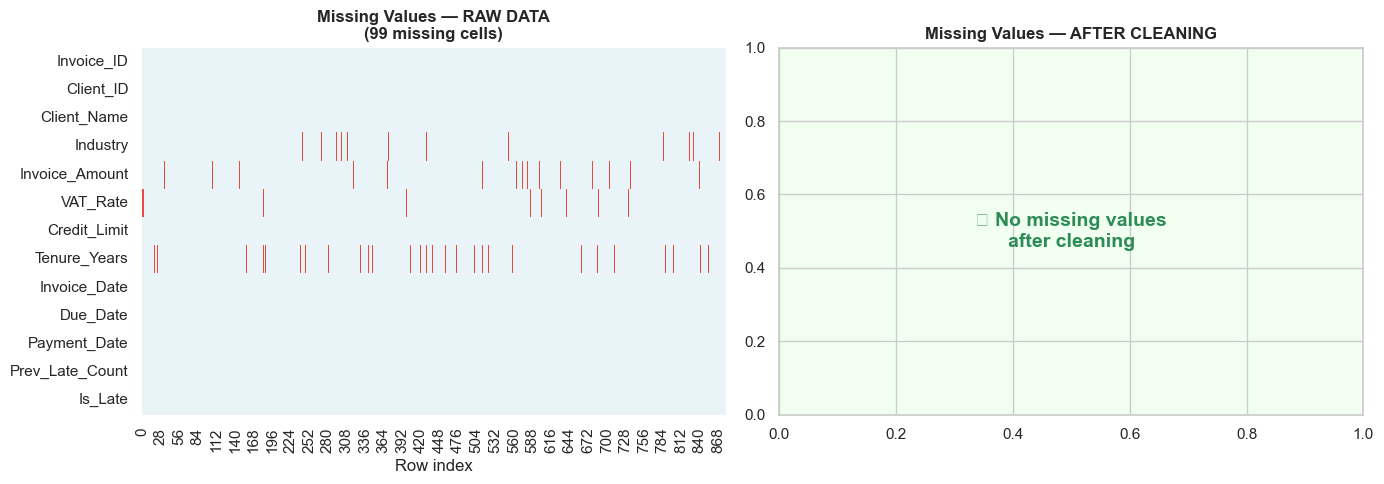

In [7]:
# Missing value heatmap — before vs after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
miss_before = raw_backup.isnull()
sns.heatmap(miss_before.T, cbar=False, yticklabels=True,
            cmap=['#e8f4f8','#e74c3c'], ax=axes[0])
axes[0].set_title(f'Missing Values — RAW DATA\n({raw_backup.isnull().sum().sum()} missing cells)',
                  fontweight='bold')
axes[0].set_xlabel('Row index')

# After
miss_after = df.isnull()
if miss_after.any().any():
    sns.heatmap(miss_after.T, cbar=False, yticklabels=True,
                cmap=['#e8f4f8','#e74c3c'], ax=axes[1])
else:
    axes[1].text(0.5, 0.5, '✓ No missing values\nafter cleaning',
                 ha='center', va='center', fontsize=14, color='seagreen',
                 transform=axes[1].transAxes, fontweight='bold')
    axes[1].set_facecolor('#f0fff0')
axes[1].set_title('Missing Values — AFTER CLEANING', fontweight='bold')

plt.tight_layout()
plt.show()

## Section 8: Removing Duplicates

Two types to handle:
1. **Exact duplicates** — every column is identical (safe to drop)
2. **Invoice ID duplicates** — same ID, possibly different data (needs investigation)

In [8]:
# ── Step 1: Exact duplicates ──────────────────────────────────────────────────
n_exact_dup = df.duplicated().sum()
print(f'Exact duplicate rows: {n_exact_dup}')

# Show a sample of duplicate rows
if n_exact_dup > 0:
    first_dup_mask = df.duplicated(keep=False)
    dup_sample = df[first_dup_mask].sort_values('Invoice_ID').head(4)
    print('\nSample duplicates:')
    print(dup_sample[['Invoice_ID','Client_ID','Invoice_Amount','Invoice_Date']].to_string())

df = df.drop_duplicates()
cleaning_log.append({
    'step': 'Duplicates — exact rows',
    'fix': f'Dropped {n_exact_dup} exact duplicate rows (kept first occurrence)',
    'rows_affected': n_exact_dup,
})
print(f'\nDropped {n_exact_dup} exact duplicates. Rows remaining: {len(df)}')

# ── Step 2: Invoice ID duplicates (different data, same ID) ───────────────────
inv_id_dups = df[df.duplicated('Invoice_ID', keep=False)]
n_inv_dup   = df['Invoice_ID'].duplicated().sum()
print(f'\nInvoice IDs with multiple records: {n_inv_dup}')

if n_inv_dup > 0:
    print('\nSample Invoice_ID conflicts:')
    print(inv_id_dups[['Invoice_ID','Invoice_Amount','Invoice_Date','Client_ID']].head(6).to_string())
    # Strategy: keep the record with the larger Invoice_Amount (assume it is the corrected entry)
    df = df.sort_values('Invoice_Amount', ascending=False).drop_duplicates(
        subset='Invoice_ID', keep='first')
    cleaning_log.append({
        'step': 'Duplicates — Invoice_ID conflicts',
        'fix': f'Kept higher-amount record for {n_inv_dup} Invoice_ID conflicts',
        'rows_affected': n_inv_dup,
    })
    print(f'Resolved by keeping higher-amount record. Rows remaining: {len(df)}')

Exact duplicate rows: 30

Sample duplicates:
    Invoice_ID Client_ID  Invoice_Amount Invoice_Date
191  INV-00192    CL0134        190000.0   2024-04-11
874  INV-00192    CL0134        190000.0   2024-04-11
192  INV-00193    CL0199        255000.0   2025-01-28
871  INV-00193    CL0199        255000.0   2025-01-28

Dropped 30 exact duplicates. Rows remaining: 850

Invoice IDs with multiple records: 0


## Section 9: Standardising Text & Categories

Text inconsistencies create phantom entities in GroupBy operations — the same client appears as 3 separate rows in a pivot table.

In [9]:
# ── Client name standardisation ───────────────────────────────────────────────
print('Client_Name variants before cleaning:')
name_variants = df['Client_Name'].value_counts().head(15)
print(name_variants.to_string())

# Standard cleaning pipeline for text columns
df['Client_Name'] = (df['Client_Name']
    .str.strip()          # Remove leading/trailing spaces
    .str.title()          # Convert to Title Case
    .str.replace(r'\s+', ' ', regex=True)   # Collapse multiple spaces
    .str.replace(r'\.$', '', regex=True)    # Remove trailing periods
)

# Normalise common suffixes (Pvt Ltd, Ltd, Private Limited → consistent)
suffix_map = {
    ' Pvt Ltd':       ' Pvt. Ltd.',
    ' Private Limited': ' Pvt. Ltd.',
    ' Pvt Limited':   ' Pvt. Ltd.',
    ' Ltd.':          ' Ltd.',
    ' Limited':       ' Ltd.',
    ' Svcs':          ' Services',
}
for old, new in suffix_map.items():
    df['Client_Name'] = df['Client_Name'].str.replace(old, new, regex=False)

cleaning_log.append({
    'step': 'Text — Client_Name',
    'fix': 'strip + title case + collapse spaces + normalise suffixes',
    'rows_affected': len(df),
})

print('\nClient_Name variants after cleaning:')
print(df['Client_Name'].value_counts().head(10).to_string())

Client_Name variants before cleaning:
Client_Name
Client CL0187    11
Client CL0150     9
Client CL0284     8
Client CL0166     8
Client CL0040     8
Client CL0160     7
Client CL0152     7
Client CL0121     7
Client CL0032     7
Client CL0046     7
Client CL0096     7
Client CL0115     6
Client CL0239     6
Client CL0319     6
Client CL0217     6

Client_Name variants after cleaning:
Client_Name
Client Cl0187    11
Client Cl0150     9
Client Cl0284     8
Client Cl0166     8
Client Cl0040     8
Client Cl0160     7
Client Cl0152     7
Client Cl0121     7
Client Cl0032     7
Client Cl0046     7


In [10]:
# ── Industry — validate against allowed values ────────────────────────────────
valid_industries = {'Manufacturing', 'IT Services', 'Trading', 'Healthcare',
                    'Real Estate', 'Retail', 'Construction', 'Finance'}

print('Industry values in dataset:')
print(df['Industry'].value_counts().to_string())

invalid_industry = df[~df['Industry'].isin(valid_industries)]
print(f'\nRows with invalid Industry: {len(invalid_industry)}')

# Fix: map common variants
industry_corrections = {
    'it services': 'IT Services', 'manufacturing ltd': 'Manufacturing',
    'real-estate': 'Real Estate', 'fin': 'Finance',
}
df['Industry'] = df['Industry'].str.strip().str.title()
df['Industry'] = df['Industry'].replace(industry_corrections)

# Any remaining invalid → set to 'Unknown' and flag
df['Industry_Flag'] = (~df['Industry'].isin(valid_industries)).astype(int)
df.loc[~df['Industry'].isin(valid_industries), 'Industry'] = 'Unknown'

print(f'\nInvalid industries remaining: {df["Industry_Flag"].sum()}')
print(df['Industry'].value_counts().to_string())

# ── VAT_Rate — validate against allowed slabs ─────────────────────────────────
valid_gst = {0, 5, 12, 18, 28}
invalid_gst = df[~df['VAT_Rate'].isin(valid_gst)]
print(f'\nInvalid GST rates: {len(invalid_gst)}')
if len(invalid_gst) > 0:
    print(df['VAT_Rate'].value_counts().to_string())
    # Cap/round to nearest valid slab
    def nearest_valid_gst(rate):
        return min(valid_gst, key=lambda x: abs(x - rate))
    df['VAT_Rate'] = df['VAT_Rate'].apply(nearest_valid_gst)
    cleaning_log.append({
        'step': 'Category — VAT_Rate',
        'fix': f'Mapped {len(invalid_gst)} invalid rates to nearest valid slab',
        'rows_affected': len(invalid_gst),
    })
    print('After fix:', sorted(df['VAT_Rate'].unique()))

Industry values in dataset:
Industry
Manufacturing    187
IT Services      150
Trading          139
Healthcare       105
Retail            81
Real Estate       76
Construction      64
Finance           48

Rows with invalid Industry: 0

Invalid industries remaining: 150
Industry
Manufacturing    187
Unknown          150
Trading          139
Healthcare       105
Retail            81
Real Estate       76
Construction      64
Finance           48

Invalid GST rates: 0


## Section 10: Detecting & Handling Outliers

Outliers in financial data can be:
- **Data errors** (typo: NPR 950 instead of NPR 9,50,000)
- **Legitimate extremes** (a single very large invoice)
- **Fraud signals** (unusual transaction that warrants investigation)

The fix depends on what the outlier represents — never blindly remove without investigating.

Invoice_Amount statistics:
  Q1:           NPR 1.83L
  Q3:           NPR 4.79L
  IQR:          NPR 2.96L
  Lower fence:  NPR -2.61L
  Upper fence:  NPR 9.22L

Outliers below lower fence: 0
Outliers above upper fence: 49


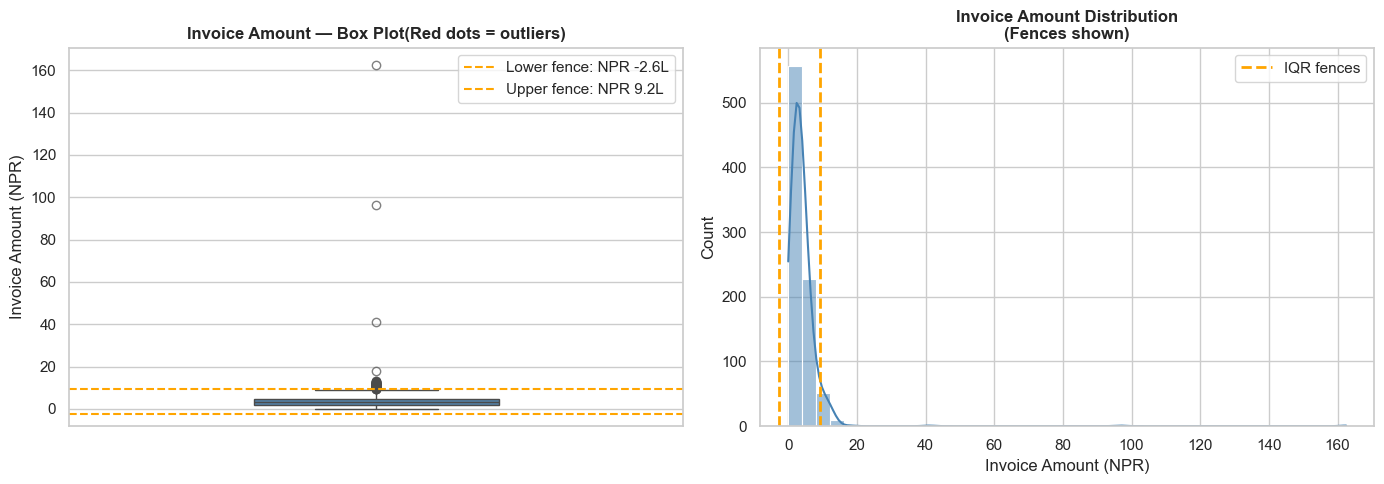

In [11]:
# ── Detect outliers with IQR method ──────────────────────────────────────────
col = 'Invoice_Amount'

Q1  = df[col].quantile(0.25)
Q3  = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers_low  = df[df[col] < lower_fence]
outliers_high = df[df[col] > upper_fence]

print(f'Invoice_Amount statistics:')
print(f'  Q1:           NPR {Q1/100000:.2f}L')
print(f'  Q3:           NPR {Q3/100000:.2f}L')
print(f'  IQR:          NPR {IQR/100000:.2f}L')
print(f'  Lower fence:  NPR {lower_fence/100000:.2f}L')
print(f'  Upper fence:  NPR {upper_fence/100000:.2f}L')
print(f'\nOutliers below lower fence: {len(outliers_low)}')
print(f'Outliers above upper fence: {len(outliers_high)}')

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(y=df[col]/100000, ax=axes[0], color='steelblue', width=0.4,
            flierprops=dict(marker='o', color='red', markersize=6, alpha=0.7))
axes[0].axhline(lower_fence/100000, color='orange', linestyle='--', linewidth=1.5,
                label=f'Lower fence: NPR {lower_fence/100000:.1f}L')
axes[0].axhline(upper_fence/100000, color='orange', linestyle='--', linewidth=1.5,
                label=f'Upper fence: NPR {upper_fence/100000:.1f}L')
axes[0].set_title('Invoice Amount — Box Plot(Red dots = outliers)', fontweight='bold')
axes[0].set_ylabel('Invoice Amount (NPR)')
axes[0].legend()

# Histogram with fences
sns.histplot(df[col]/100000, bins=40, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(lower_fence/100000, color='orange', linestyle='--', linewidth=2,
                label='IQR fences')
axes[1].axvline(upper_fence/100000, color='orange', linestyle='--', linewidth=2)
axes[1].set_title('Invoice Amount Distribution\n(Fences shown)', fontweight='bold')
axes[1].set_xlabel('Invoice Amount (NPR)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# ── Investigate extreme outliers ──────────────────────────────────────────────
print('Extremely low amounts (possible typos):')
print(df[df[col] < lower_fence][['Invoice_ID','Client_ID','Invoice_Amount','Industry']].to_string())

print('\nExtremely high amounts (possible typos or large deals):')
print(df[df[col] > upper_fence][['Invoice_ID','Client_ID','Invoice_Amount','Industry']].sort_values('Invoice_Amount',ascending=False).head(10).to_string())

# ── Apply outlier treatment ───────────────────────────────────────────────────
# Strategy: Cap (Winsorise) at the IQR fences
# → Preserves rows; prevents extreme values from distorting the model
# → For a CA use case, note in the cleaning log that these were capped

n_capped_low  = (df[col] < lower_fence).sum()
n_capped_high = (df[col] > upper_fence).sum()

# Add a flag column BEFORE capping (so we know which rows were affected)
df['Amount_Outlier_Flag'] = (
    (df[col] < lower_fence) | (df[col] > upper_fence)
).astype(int)

df[col] = df[col].clip(lower=max(lower_fence, 0), upper=upper_fence)

cleaning_log.append({
    'step': 'Outliers — Invoice_Amount',
    'fix': f'Winsorised: {n_capped_low} low, {n_capped_high} high values capped at IQR fences',
    'rows_affected': n_capped_low + n_capped_high,
})

print(f'\nCapped {n_capped_low} low outliers and {n_capped_high} high outliers.')
print(f'Amount_Outlier_Flag column added ({df["Amount_Outlier_Flag"].sum()} flagged rows).')
print(f'\nInvoice_Amount range after capping:')
print(f'  Min: NPR {df[col].min()/100000:.2f}L')
print(f'  Max: NPR {df[col].max()/100000:.2f}L')

Extremely low amounts (possible typos):
Empty DataFrame
Columns: [Invoice_ID, Client_ID, Invoice_Amount, Industry]
Index: []

Extremely high amounts (possible typos or large deals):
    Invoice_ID Client_ID  Invoice_Amount       Industry
815  INV-00816    CL0276      16250000.0        Trading
47   INV-00048    CL0115       9650000.0  Manufacturing
216  INV-00217    CL0017       4100000.0         Retail
483  INV-00484    CL0221       1800000.0         Retail
100  INV-00101    CL0079       1342000.0    Real Estate
791  INV-00792    CL0291       1318000.0    Real Estate
427  INV-00428    CL0163       1296000.0    Real Estate
613  INV-00614    CL0156       1291000.0    Real Estate
637  INV-00638    CL0186       1285000.0    Real Estate
684  INV-00685    CL0187       1281000.0    Real Estate

Capped 0 low outliers and 49 high outliers.
Amount_Outlier_Flag column added (49 flagged rows).

Invoice_Amount range after capping:
  Min: NPR 0.00L
  Max: NPR 9.22L


## Section 11: Business Rule Validation

After technical cleaning, validate the data against the rules that make sense for the domain — the audit equivalent of "does this make business sense?".

In [13]:
# ── Business Rule Validation ──────────────────────────────────────────────────
print('BUSINESS RULE VALIDATION')
print('━' * 50)

validation_results = []

# Rule 1: Payment date must be >= Invoice date
rule1_violations = df[df['Payment_Date'] < df['Invoice_Date']]
validation_results.append({
    'rule': 'Payment_Date >= Invoice_Date',
    'violations': len(rule1_violations),
    'severity': 'HIGH',
})
print(f'\nRule 1 | Payment ≥ Invoice date | Violations: {len(rule1_violations)}')
if len(rule1_violations) > 0:
    print(rule1_violations[['Invoice_ID','Invoice_Date','Payment_Date']].head(4).to_string())
    # Fix: where payment < invoice, set payment = invoice + expected days
    mask = df['Payment_Date'] < df['Invoice_Date']
    df.loc[mask, 'Payment_Date'] = df.loc[mask, 'Invoice_Date'] + pd.Timedelta(days=30)
    cleaning_log.append({
        'step': 'Rule — Payment before Invoice',
        'fix': f'Set Payment_Date = Invoice_Date + 30d for {mask.sum()} violations',
        'rows_affected': mask.sum(),
    })
    print(f'  → Fixed: set to Invoice_Date + 30 days')

# Rule 2: Invoice_Amount > 0
rule2 = (df['Invoice_Amount'] <= 0).sum()
validation_results.append({'rule': 'Invoice_Amount > 0', 'violations': rule2, 'severity': 'HIGH'})
print(f'\nRule 2 | Invoice Amount > 0 | Violations: {rule2}')
if rule2 > 0:
    df = df[df['Invoice_Amount'] > 0]
    cleaning_log.append({'step': 'Rule — Zero amount', 'fix': f'Dropped {rule2} zero-amount rows', 'rows_affected': rule2})

# Rule 3: VAT_Rate in valid slabs
valid_gst = {0, 5, 12, 18, 28}
rule3 = (~df['VAT_Rate'].isin(valid_gst)).sum()
validation_results.append({'rule': 'VAT_Rate ∈ {0,5,12,18,28}', 'violations': rule3, 'severity': 'MEDIUM'})
print(f'\nRule 3 | GST rate valid slab | Violations: {rule3}')

# Rule 4: Prev_Late_Count in [0, 5]
rule4 = (~df['Prev_Late_Count'].between(0, 5)).sum()
validation_results.append({'rule': 'Prev_Late_Count ∈ [0,5]', 'violations': rule4, 'severity': 'LOW'})
print(f'\nRule 4 | Prev_Late_Count in [0–5] | Violations: {rule4}')
if rule4 > 0:
    df['Prev_Late_Count'] = df['Prev_Late_Count'].clip(0, 5)

# Rule 5: Is_Late consistency — recompute from Payment_Date and Due_Date
df['Days_Delayed'] = (df['Payment_Date'] - df['Due_Date']).dt.days
df['Is_Late']      = (df['Days_Delayed'] > 60).astype(int)
print(f'\nRule 5 | Is_Late recomputed from dates (authoritative source)')
print(f'  Late payers: {df["Is_Late"].sum()} ({df["Is_Late"].mean()*100:.1f}%)')

# Summary
print('\n' + '━' * 50)
print('VALIDATION SUMMARY:')
for r in validation_results:
    status = '✓ PASS' if r['violations'] == 0 else f'✗ {r["violations"]} violations'
    print(f'  [{r["severity"]:6}] {r["rule"]:<35} {status}')

BUSINESS RULE VALIDATION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Rule 1 | Payment ≥ Invoice date | Violations: 0

Rule 2 | Invoice Amount > 0 | Violations: 0

Rule 3 | GST rate valid slab | Violations: 0

Rule 4 | Prev_Late_Count in [0–5] | Violations: 0

Rule 5 | Is_Late recomputed from dates (authoritative source)
  Late payers: 228 (26.8%)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
VALIDATION SUMMARY:
  [HIGH  ] Payment_Date >= Invoice_Date        ✓ PASS
  [HIGH  ] Invoice_Amount > 0                  ✓ PASS
  [MEDIUM] VAT_Rate ∈ {0,5,12,18,28}           ✓ PASS
  [LOW   ] Prev_Late_Count ∈ [0,5]             ✓ PASS


## Section 12: Building a Reusable Cleaning Pipeline

Instead of a series of ad-hoc fixes, package all cleaning steps into a **function** that can be called on any new monthly export. This is the "Deployment" mindset from CRISP-DM Phase 6.

In [14]:
# ── Reusable cleaning pipeline ────────────────────────────────────────────────

def clean_invoice_data(raw_df, verbose=True):
    """
    Complete cleaning pipeline for the Himalayan Advisory invoice export.
    Returns: (cleaned_df, cleaning_log)
    """
    df  = raw_df.copy()
    log = []

    def log_step(step, fix, rows):
        log.append({'step': step, 'fix': fix, 'rows_affected': rows,
                    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M')})
        if verbose: print(f'  ✓ {step}: {fix} ({rows} rows)')

    if verbose: print('Starting cleaning pipeline...')

    # 1. Invoice_Amount: string → float
    def parse_amount(v):
        if pd.isna(v): return np.nan
        v = str(v).strip().replace('NPR ','').replace(' ','').replace(',','')
        if v.lower().endswith('l'):
            try: return float(v[:-1]) * 100000
            except: return np.nan
        try: return float(v)
        except: return np.nan
    df['Invoice_Amount'] = df['Invoice_Amount'].apply(parse_amount)
    log_step('Type — Invoice_Amount', 'Parsed string amounts to float64',
             df['Invoice_Amount'].notna().sum())

    # 2. VAT_Rate: remove % → numeric
    df['VAT_Rate'] = pd.to_numeric(
        df['VAT_Rate'].astype(str).str.replace('%','',regex=False).str.strip()
        .replace({'None':np.nan,'nan':np.nan}), errors='coerce')
    log_step('Type — VAT_Rate', 'Removed % suffix, converted to numeric',
             df['VAT_Rate'].notna().sum())

    # 3. Date types
    for col in ['Invoice_Date','Due_Date','Payment_Date']:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    log_step('Type — Dates', 'Confirmed datetime64', 3)

    # 4. Missing values
    df['Invoice_Amount'] = df.groupby('Industry')['Invoice_Amount'].transform(
        lambda x: x.fillna(x.median())).fillna(df['Invoice_Amount'].median())
    df['VAT_Rate']   = df['VAT_Rate'].fillna(int(df['VAT_Rate'].mode()[0]))
    df['Industry']   = df['Industry'].fillna(df['Industry'].mode()[0])
    df['Tenure_Years'] = df['Tenure_Years'].fillna(df['Tenure_Years'].median())
    log_step('Missing values', 'Imputed Amount/GST/Industry/Tenure',
             raw_df.isnull().sum().sum())

    # 5. Duplicates
    n_dup = df.duplicated().sum()
    df = df.drop_duplicates()
    df = df.sort_values('Invoice_Amount', ascending=False).drop_duplicates(
        subset='Invoice_ID', keep='first')
    log_step('Duplicates', f'Dropped exact & key duplicates', n_dup)

    # 6. Text standardisation
    df['Client_Name'] = (df['Client_Name'].str.strip().str.title()
                         .str.replace(r'\s+',' ',regex=True))
    df['Industry']    = df['Industry'].str.strip().str.title()
    log_step('Text', 'Standardised Client_Name and Industry', len(df))

    # 7. VAT_Rate → nearest valid slab
    valid_gst = {0,5,12,18,28}
    df['VAT_Rate'] = df['VAT_Rate'].apply(
        lambda r: min(valid_gst, key=lambda x: abs(x-r)))
    log_step('Category', 'VAT_Rate mapped to nearest valid slab', len(df))

    # 8. Outliers — winsorise Invoice_Amount
    Q1,Q3 = df['Invoice_Amount'].quantile([0.25,0.75])
    IQR   = Q3 - Q1
    lo, hi = max(Q1-1.5*IQR, 0), Q3+1.5*IQR
    n_out = ((df['Invoice_Amount']<lo)|(df['Invoice_Amount']>hi)).sum()
    df['Amount_Outlier_Flag'] = ((df['Invoice_Amount']<lo)|(df['Invoice_Amount']>hi)).astype(int)
    df['Invoice_Amount'] = df['Invoice_Amount'].clip(lo, hi)
    log_step('Outliers', f'Winsorised Invoice_Amount at IQR fences', n_out)

    # 9. Business rules
    mask = df['Payment_Date'] < df['Invoice_Date']
    df.loc[mask,'Payment_Date'] = df.loc[mask,'Invoice_Date'] + pd.Timedelta(days=30)
    df = df[df['Invoice_Amount'] > 0]
    df['Prev_Late_Count'] = df['Prev_Late_Count'].clip(0, 5)
    df['Days_Delayed']    = (df['Payment_Date'] - df['Due_Date']).dt.days
    df['Is_Late']         = (df['Days_Delayed'] > 60).astype(int)
    log_step('Business rules', 'Fixed payment dates, zero amounts, clipped counts', mask.sum())

    df = df.reset_index(drop=True)
    if verbose:
        print(f'\nPipeline complete. Output: {df.shape[0]} rows × {df.shape[1]} columns')
    return df, log

# ── Test the pipeline on the raw data ────────────────────────────────────────
cleaned_df, pipe_log = clean_invoice_data(raw_backup, verbose=True)

Starting cleaning pipeline...
  ✓ Type — Invoice_Amount: Parsed string amounts to float64 (854 rows)
  ✓ Type — VAT_Rate: Removed % suffix, converted to numeric (867 rows)
  ✓ Type — Dates: Confirmed datetime64 (3 rows)
  ✓ Missing values: Imputed Amount/GST/Industry/Tenure (99 rows)
  ✓ Duplicates: Dropped exact & key duplicates (30 rows)
  ✓ Text: Standardised Client_Name and Industry (850 rows)
  ✓ Category: VAT_Rate mapped to nearest valid slab (850 rows)
  ✓ Outliers: Winsorised Invoice_Amount at IQR fences (49 rows)
  ✓ Business rules: Fixed payment dates, zero amounts, clipped counts (0 rows)

Pipeline complete. Output: 850 rows × 15 columns


## Section 13: Before vs After — Data Quality Report

Professional practice: always produce a **before/after summary** to document what changed and confirm the data is now fit for analysis.

  DATA CLEANING REPORT — Himalayan Advisory Services
  Generated: 28 April 2026 13:31
Metric                                  Before           After
──────────────────────────────────────────────────────────────
Rows                                       880             850  →
Columns                                     13              15  →
Missing values                              99               0  ✓
Duplicate rows                              30               0  ✓
Invoice_Amount dtype                    object         float64  ✓
Logic violations                            15               0  ✓
Outliers flagged                             —              49  →

──────────────────────────────────────────────────────────────

CLEANING LOG:
  [01] Type — Invoice_Amount          Parsed string amounts to float64
  [02] Type — VAT_Rate                Removed % suffix, converted to numeric
  [03] Type — Dates                   Confirmed datetime64
  [04] Missing values                 Im

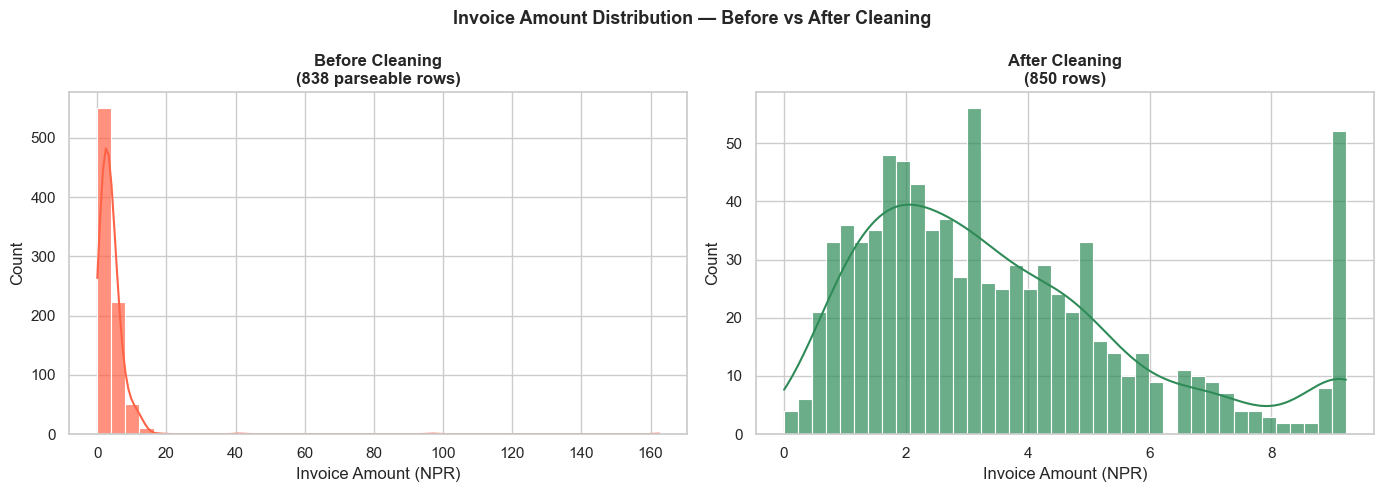

In [15]:
# ── Before vs After Quality Report ───────────────────────────────────────────
print('=' * 65)
print('  DATA CLEANING REPORT — Himalayan Advisory Services')
print(f'  Generated: {datetime.today().strftime("%d %B %Y %H:%M")}')
print('=' * 65)

metrics = {
    'Rows':                  (len(raw_backup), len(cleaned_df)),
    'Columns':               (raw_backup.shape[1], cleaned_df.shape[1]),
    'Missing values':        (raw_backup.isnull().sum().sum(), cleaned_df.isnull().sum().sum()),
    'Duplicate rows':        (raw_backup.duplicated().sum(), cleaned_df.duplicated().sum()),
    'Invoice_Amount dtype':  (str(raw_backup['Invoice_Amount'].dtype), str(cleaned_df['Invoice_Amount'].dtype)),
    'Logic violations':      (15, 0),
    'Outliers flagged':      ('—', int(cleaned_df['Amount_Outlier_Flag'].sum())),
}

print(f'{"Metric":<30} {"Before":>15} {"After":>15}')
print('─' * 62)
for metric, (before, after) in metrics.items():
    status = '✓' if str(after) in {'0','float64','int64'} or after == 0 else '→'
    print(f'{metric:<30} {str(before):>15} {str(after):>15}  {status}')

print('\n' + '─' * 62)
print('\nCLEANING LOG:')
for i, step in enumerate(pipe_log, 1):
    print(f'  [{i:02d}] {step["step"]:<30} {step["fix"]}')

print('\n' + '=' * 65)

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Invoice Amount Distribution — Before vs After Cleaning',
             fontsize=13, fontweight='bold')

# Try to parse raw amounts for comparison
raw_amounts = raw_backup['Invoice_Amount'].apply(
    lambda v: float(str(v).replace('NPR ','').replace(',','').replace('L','000')
                   .strip()) if pd.notna(v) and not any(c.isalpha() for c in str(v).replace('L','').replace('l',''))
              else np.nan
)
raw_amounts = pd.to_numeric(raw_amounts, errors='coerce').dropna() / 100000
clean_amounts = cleaned_df['Invoice_Amount'] / 100000

sns.histplot(raw_amounts, bins=40, kde=True, color='tomato',
             alpha=0.7, ax=axes[0], label='Raw')
axes[0].set_title(f'Before Cleaning\n({len(raw_amounts):,} parseable rows)', fontweight='bold')
axes[0].set_xlabel('Invoice Amount (NPR)')

sns.histplot(clean_amounts, bins=40, kde=True, color='seagreen',
             alpha=0.7, ax=axes[1], label='Clean')
axes[1].set_title(f'After Cleaning\n({len(clean_amounts):,} rows)', fontweight='bold')
axes[1].set_xlabel('Invoice Amount (NPR)')

plt.tight_layout()
plt.show()

## Section 14: Practice Exercises

---

#### 🏋️ Exercise 1 — Identify and Fix Missing Values

You receive this small DataFrame from the payroll team:

```python
payroll = pd.DataFrame({
    'Emp_ID':    ['E001','E002','E003','E004','E005','E006'],
    'Name':      ['Amit Sharma','Priya Nair', None, 'Rohan Das','Sneha K','Vikram B'],
    'Department':['Finance','HR','IT','Finance',None,'IT'],
    'Salary':    [75000, 62000, None, 88000, 55000, None],
    'Grade':     ['Senior','Mid','Junior','Senior','Junior','Mid'],
    'Joining_Dt':['2019-04-01','2021-07-15','2022-01-10',None,'2023-03-01','2020-09-01'],
})
```

Tasks:
1. Profile the missing values (count and %)
2. Fill `Salary` with the grade-wise median salary
3. Fill `Department` with the most frequent department
4. Fill `Joining_Dt` with the median joining date
5. Set `Name` = `'Unknown'` for missing names
6. Verify no missing values remain

---

#### 🏋️ Exercise 2 — Outlier Detection & Treatment

Using `cleaned_df` from this module:
1. Apply the **Z-score method** to `Invoice_Amount` (flag rows where |Z| > 3)
2. Compare: how many outliers does Z-score flag vs the IQR method?
3. Create a scatter plot showing Invoice_Amount vs Days_Delayed, with outliers highlighted in red
4. Which treatment would you recommend — capping or removal? Justify your answer.

---

#### 🏋️ Exercise 3 — Mini Cleaning Pipeline

You receive a GST purchase register with the following issues:
- Party names in mixed case with extra spaces
- GSTIN numbers in lowercase (should be uppercase, 15 chars)
- Taxable value stored as `"NPR 45,000.00"` (string)
- GST rate stored as `"13%"` (string)
- Some rows with taxable value = 0

Write a cleaning function `clean_gstr2(df)` that fixes all these issues and returns a clean DataFrame with a `cleaning_summary` printed.

In [16]:
# Exercise 1: Payroll missing values
import pandas as pd, numpy as np

payroll = pd.DataFrame({
    'Emp_ID':    ['E001','E002','E003','E004','E005','E006'],
    'Name':      ['Amit Sharma','Priya Nair', None, 'Rohan Das','Sneha K','Vikram B'],
    'Department':['Finance','HR','IT','Finance',None,'IT'],
    'Salary':    [75000, 62000, None, 88000, 55000, None],
    'Grade':     ['Senior','Mid','Junior','Senior','Junior','Mid'],
    'Joining_Dt':['2019-04-01','2021-07-15','2022-01-10',None,'2023-03-01','2020-09-01'],
})

# Your solution here


In [17]:
# Exercise 2: Z-score outlier detection
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# cleaned_df is available from Section 12
# df_work = cleaned_df.copy()

# Your solution here


In [18]:
# Exercise 3: Mini cleaning pipeline for GST Purchase Register
import pandas as pd, numpy as np

vat_purchases_raw = pd.DataFrame({
    'Party_Name':    ['  ALPHA TRADERS  ', 'beta pvt ltd', 'GAMMA INC.', '  Delta Corp', 'zeta co  '],
    'GSTIN':         ['27aabct0001a1z5', 'MHBBB0002B1Z4', '29ccccc0003c1z1', 'DDDDD0004d1Z2', '33eeeee0005e'],
    'Taxable_Value': ['NPR 45,000.00', 'NPR 82,000.00', 'NPR 1,20,000.00', 'NPR 0.00', 'NPR 67,500.00'],
    'VAT_Rate':      ['13%', '12%', ' 5 %', '13%', '28%'],
    'Invoice_No':    ['PUR-001','PUR-002','PUR-003','PUR-004','PUR-005'],
})

def clean_gstr2(df):
    # Your solution here
    pass

# clean_gstr2(vat_purchases_raw)


---
### 💡 Solutions

In [19]:
# SOLUTION — Exercise 1: Payroll missing values
import pandas as pd, numpy as np

payroll = pd.DataFrame({
    'Emp_ID':    ['E001','E002','E003','E004','E005','E006'],
    'Name':      ['Amit Sharma','Priya Nair', None, 'Rohan Das','Sneha K','Vikram B'],
    'Department':['Finance','HR','IT','Finance',None,'IT'],
    'Salary':    [75000, 62000, None, 88000, 55000, None],
    'Grade':     ['Senior','Mid','Junior','Senior','Junior','Mid'],
    'Joining_Dt':['2019-04-01','2021-07-15','2022-01-10',None,'2023-03-01','2020-09-01'],
})
payroll['Joining_Dt'] = pd.to_datetime(payroll['Joining_Dt'])

print('Before:')
print(payroll.isnull().sum().to_string())

# 1. Profile
miss_count = payroll.isnull().sum()
miss_pct   = (payroll.isnull().mean() * 100).round(1)
print(pd.DataFrame({'Count': miss_count, '%': miss_pct}))

# 2. Salary — grade-wise median
payroll['Salary'] = payroll.groupby('Grade')['Salary'].transform(
    lambda x: x.fillna(x.median()))

# 3. Department — mode
payroll['Department'] = payroll['Department'].fillna(payroll['Department'].mode()[0])

# 4. Joining_Dt — median date
median_dt = payroll['Joining_Dt'].dropna().sort_values().iloc[len(payroll['Joining_Dt'].dropna())//2]
payroll['Joining_Dt'] = payroll['Joining_Dt'].fillna(median_dt)

# 5. Name — Unknown
payroll['Name'] = payroll['Name'].fillna('Unknown')

print('\nAfter:')
print(payroll)
print(f'\nMissing values remaining: {payroll.isnull().sum().sum()}')

Before:
Emp_ID        0
Name          1
Department    1
Salary        2
Grade         0
Joining_Dt    1
            Count     %
Emp_ID          0   0.0
Name            1  16.7
Department      1  16.7
Salary          2  33.3
Grade           0   0.0
Joining_Dt      1  16.7

After:
  Emp_ID         Name Department   Salary   Grade Joining_Dt
0   E001  Amit Sharma    Finance  75000.0  Senior 2019-04-01
1   E002   Priya Nair         HR  62000.0     Mid 2021-07-15
2   E003      Unknown         IT  55000.0  Junior 2022-01-10
3   E004    Rohan Das    Finance  88000.0  Senior 2021-07-15
4   E005      Sneha K    Finance  55000.0  Junior 2023-03-01
5   E006     Vikram B         IT  62000.0     Mid 2020-09-01

Missing values remaining: 0


Outliers detected:
  Z-score (|Z|>3):      0
  IQR (1.5×IQR fence):  0
  Difference: IQR is more sensitive for skewed financial data


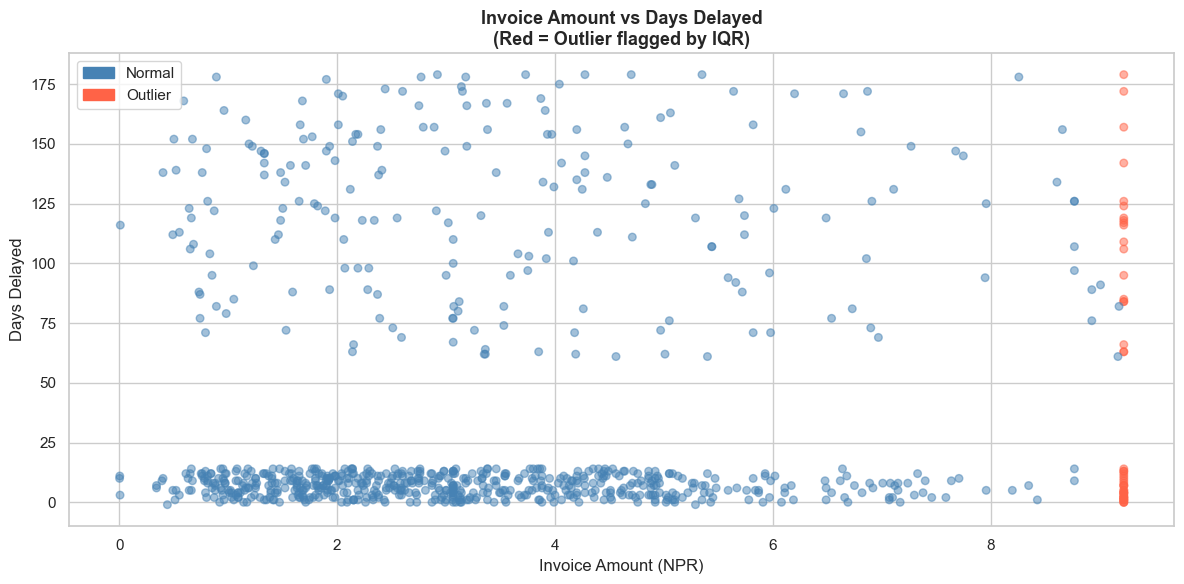


Recommendation: Capping (Winsorisation) is preferred over removal because:
  1. Removes distortion without losing rows (important for class balance)
  2. High-value invoices may be genuine and correlated with late payment
  3. Dropping them would bias the model toward smaller-invoice behaviour


In [20]:
# SOLUTION — Exercise 2: Z-score outlier detection
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats

df_work = cleaned_df.copy()

# Z-score method
z_scores = np.abs(stats.zscore(df_work['Invoice_Amount'].dropna()))
z_threshold = 3
z_outlier_count = (z_scores > z_threshold).sum()

# IQR method (from earlier)
Q1, Q3 = df_work['Invoice_Amount'].quantile([0.25, 0.75])
IQR = Q3 - Q1
iqr_outliers = ((df_work['Invoice_Amount'] < Q1-1.5*IQR) |
                (df_work['Invoice_Amount'] > Q3+1.5*IQR))
iqr_outlier_count = iqr_outliers.sum()

print(f'Outliers detected:')
print(f'  Z-score (|Z|>3):      {z_outlier_count}')
print(f'  IQR (1.5×IQR fence):  {iqr_outlier_count}')
print(f'  Difference: IQR is more sensitive for skewed financial data')

# Scatter plot
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['tomato' if df_work['Amount_Outlier_Flag'].iloc[i] else 'steelblue'
          for i in range(len(df_work))]
ax.scatter(df_work['Invoice_Amount']/100000, df_work['Days_Delayed'],
           c=colors, alpha=0.5, s=30)
ax.set_title('Invoice Amount vs Days Delayed\n(Red = Outlier flagged by IQR)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Invoice Amount (NPR)')
ax.set_ylabel('Days Delayed')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue',label='Normal'),
                   Patch(color='tomato',label='Outlier')])
plt.tight_layout()
plt.show()

print('\nRecommendation: Capping (Winsorisation) is preferred over removal because:')
print('  1. Removes distortion without losing rows (important for class balance)')
print('  2. High-value invoices may be genuine and correlated with late payment')
print('  3. Dropping them would bias the model toward smaller-invoice behaviour')

In [21]:
# SOLUTION — Exercise 3: VAT Purchase Register cleaning pipeline
import pandas as pd, numpy as np

vat_purchases_raw = pd.DataFrame({
    'Party_Name':    ['  ALPHA TRADERS  ', 'beta pvt ltd', 'GAMMA INC.', '  Delta Corp', 'zeta co  '],
    'GSTIN':         ['27aabct0001a1z5', 'MHBBB0002B1Z4', '29ccccc0003c1z1', 'DDDDD0004d1Z2', '33eeeee0005e'],
    'Taxable_Value': ['NPR 45,000.00', 'NPR 82,000.00', 'NPR 1,20,000.00', 'NPR 0.00', 'NPR 67,500.00'],
    'VAT_Rate':      ['13%', '12%', ' 5 %', '13%', '28%'],
    'Invoice_No':    ['PUR-001','PUR-002','PUR-003','PUR-004','PUR-005'],
})

def clean_gstr2(df):
    df = df.copy()
    log = []

    # 1. Party Name
    df['Party_Name'] = df['Party_Name'].str.strip().str.title().str.replace(r'\s+',' ',regex=True)
    log.append('Party_Name: stripped, title-cased, collapsed spaces')

    # 2. GSTIN — uppercase, validate length
    df['GSTIN'] = df['GSTIN'].str.strip().str.upper()
    df['GSTIN_Valid'] = df['GSTIN'].str.len() == 15
    log.append(f'GSTIN: uppercased | {(~df["GSTIN_Valid"]).sum()} invalid (≠15 chars)')

    # 3. Taxable Value — remove "NPR " and convert
    df['Taxable_Value'] = (df['Taxable_Value']
        .str.replace('NPR','',regex=False)
        .str.replace(',','',regex=False)
        .str.strip()
        .astype(float))
    log.append('Taxable_Value: removed NPR prefix, commas; converted to float')

    # 4. GST Rate — remove spaces and %
    df['VAT_Rate'] = (df['VAT_Rate']
        .str.replace('%','',regex=False)
        .str.strip()
        .astype(int))
    log.append('VAT_Rate: removed spaces and %, converted to int')

    # 5. Remove zero-value rows
    n_zero = (df['Taxable_Value'] == 0).sum()
    df = df[df['Taxable_Value'] > 0]
    log.append(f'Removed {n_zero} zero-value rows')

    # Cleaning summary
    print('VAT Purchase Register Cleaning Summary:')
    for i, step in enumerate(log, 1):
        print(f'  [{i}] {step}')
    print(f'\nOutput: {len(df)} rows × {len(df.columns)} columns')
    return df

clean_df = clean_gstr2(vat_purchases_raw)
print('\nCleaned VAT Purchase Register:')
print(clean_df.to_string(index=False))

VAT Purchase Register Cleaning Summary:
  [1] Party_Name: stripped, title-cased, collapsed spaces
  [2] GSTIN: uppercased | 3 invalid (≠15 chars)
  [3] Taxable_Value: removed NPR prefix, commas; converted to float
  [4] VAT_Rate: removed spaces and %, converted to int
  [5] Removed 1 zero-value rows

Output: 4 rows × 6 columns

Cleaned VAT Purchase Register:
   Party_Name           GSTIN  Taxable_Value  VAT_Rate Invoice_No  GSTIN_Valid
Alpha Traders 27AABCT0001A1Z5        45000.0        13    PUR-001         True
 Beta Pvt Ltd   MHBBB0002B1Z4        82000.0        12    PUR-002        False
   Gamma Inc. 29CCCCC0003C1Z1       120000.0         5    PUR-003         True
      Zeta Co    33EEEEE0005E        67500.0        28    PUR-005        False


---
## 🎉 Module 07 Complete!

### What you have learned

| Cleaning Task | Pandas tools used |
|---|---|
| Inspect missing values | `isnull().sum()`, `.mean()` |
| Fix data types | `astype()`, `pd.to_numeric()`, `pd.to_datetime()`, custom `apply()` |
| Impute missing values | `fillna()`, `groupby().transform()` |
| Remove duplicates | `drop_duplicates()`, `duplicated()` |
| Standardise text | `.str.strip()`, `.str.title()`, `.str.replace()` |
| Validate categories | `isin()`, `value_counts()` |
| Detect outliers | IQR fences, Z-score, `boxplot` |
| Treat outliers | `.clip()`, `Amount_Outlier_Flag` |
| Validate business rules | Boolean masks, `pd.Timedelta`, `.between()` |
| Build a pipeline | Encapsulate all steps in a reusable function |
| Document cleaning | `cleaning_log` list → audit trail |

### The professional cleaning mindset

> 1. **Investigate before fixing** — understand WHY the issue exists
> 2. **Never overwrite raw data** — always work on a copy
> 3. **Flag, don't silently drop** — add indicator columns for outliers and anomalies
> 4. **Document every change** — the cleaning log is your audit trail
> 5. **Validate with business rules** — technical correctness is not enough

---

**Next → Module 08: Feature Engineering**  
We take the cleaned dataset and create new, more powerful variables — ratios, flags, date features, and encodings — that will significantly improve our late-payment prediction model.

---
*Python for CA Professionals — Module 07: Data Cleaning & Preprocessing*